# Credit Card Fraud Detection Project

### Brief Description

The **Credit Card Fraud Detection** dataset contains credit card transactions made by European cardholders during two days in September 2013. The main objective is to identify fraudulent transactions among legitimate ones. The dataset is highly imbalanced, as fraudulent transactions represent only **0.172%** of all transactions.

### Source

The dataset is provided by the **Machine Learning Group of Université Libre de Bruxelles (ULB)** and is available through Kaggle.

**Dataset:** Credit Card Fraud Detection
**Source:** Kaggle – MLG-ULB
**Link:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

### Number of Samples

The dataset contains **284,807 transactions**:

* **284,315** legitimate transactions
* **492** fraudulent transactions

This results in a highly imbalanced dataset, with fraudulent transactions accounting for approximately **0.172%** of all transactions.

### Features

The dataset contains **30 input features**:

* **V1–V28:** 28 anonymized numerical features obtained through **Principal Component Analysis (PCA)** to protect confidential information.
* **Time:** The number of seconds elapsed between each transaction and the first transaction in the dataset.
* **Amount:** The transaction amount.

The original features represented by V1–V28 are not disclosed because of confidentiality concerns.

### Target Variable

The target variable is **`Class`**, which is a binary variable:

* **0:** Legitimate transaction
* **1:** Fraudulent transaction

The extreme class imbalance makes fraud detection challenging and requires appropriate evaluation metrics and preprocessing techniques.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
print(df.shape)
df.info()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum().sum()

np.int64(0)

### Removing Duplicate Rows

The dataset initially contained **284,807 rows and 31 columns**. After removing **1,081 duplicate rows**, the dataset contains **283,726 rows and 31 columns**.

This ensures that duplicate transactions are not repeated in the dataset and helps maintain the quality of the analysis.


In [7]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (283726, 31)


### Class Distribution

After removing the duplicate rows, the dataset contains **283,726 transactions**:

* **Class 0 (Legitimate):** 283,253 transactions
* **Class 1 (Fraudulent):** 473 transactions

The dataset is **highly imbalanced**, as fraudulent transactions represent only a very small proportion of the total transactions.


In [8]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

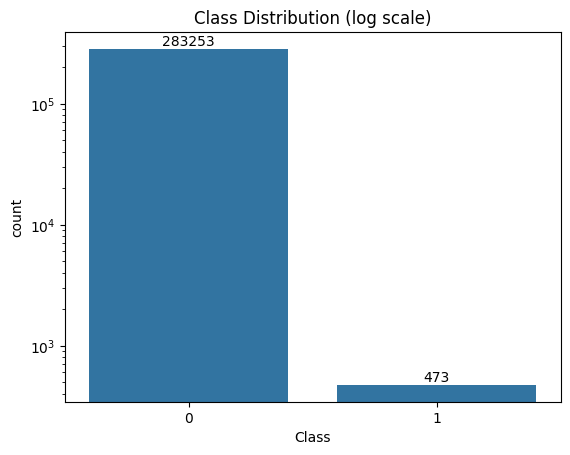

In [9]:
ax = sns.countplot(x='Class', data=df)
ax.set_yscale('log')
for c in ax.containers:
    ax.bar_label(c)
plt.title('Class Distribution (log scale)')
plt.show()

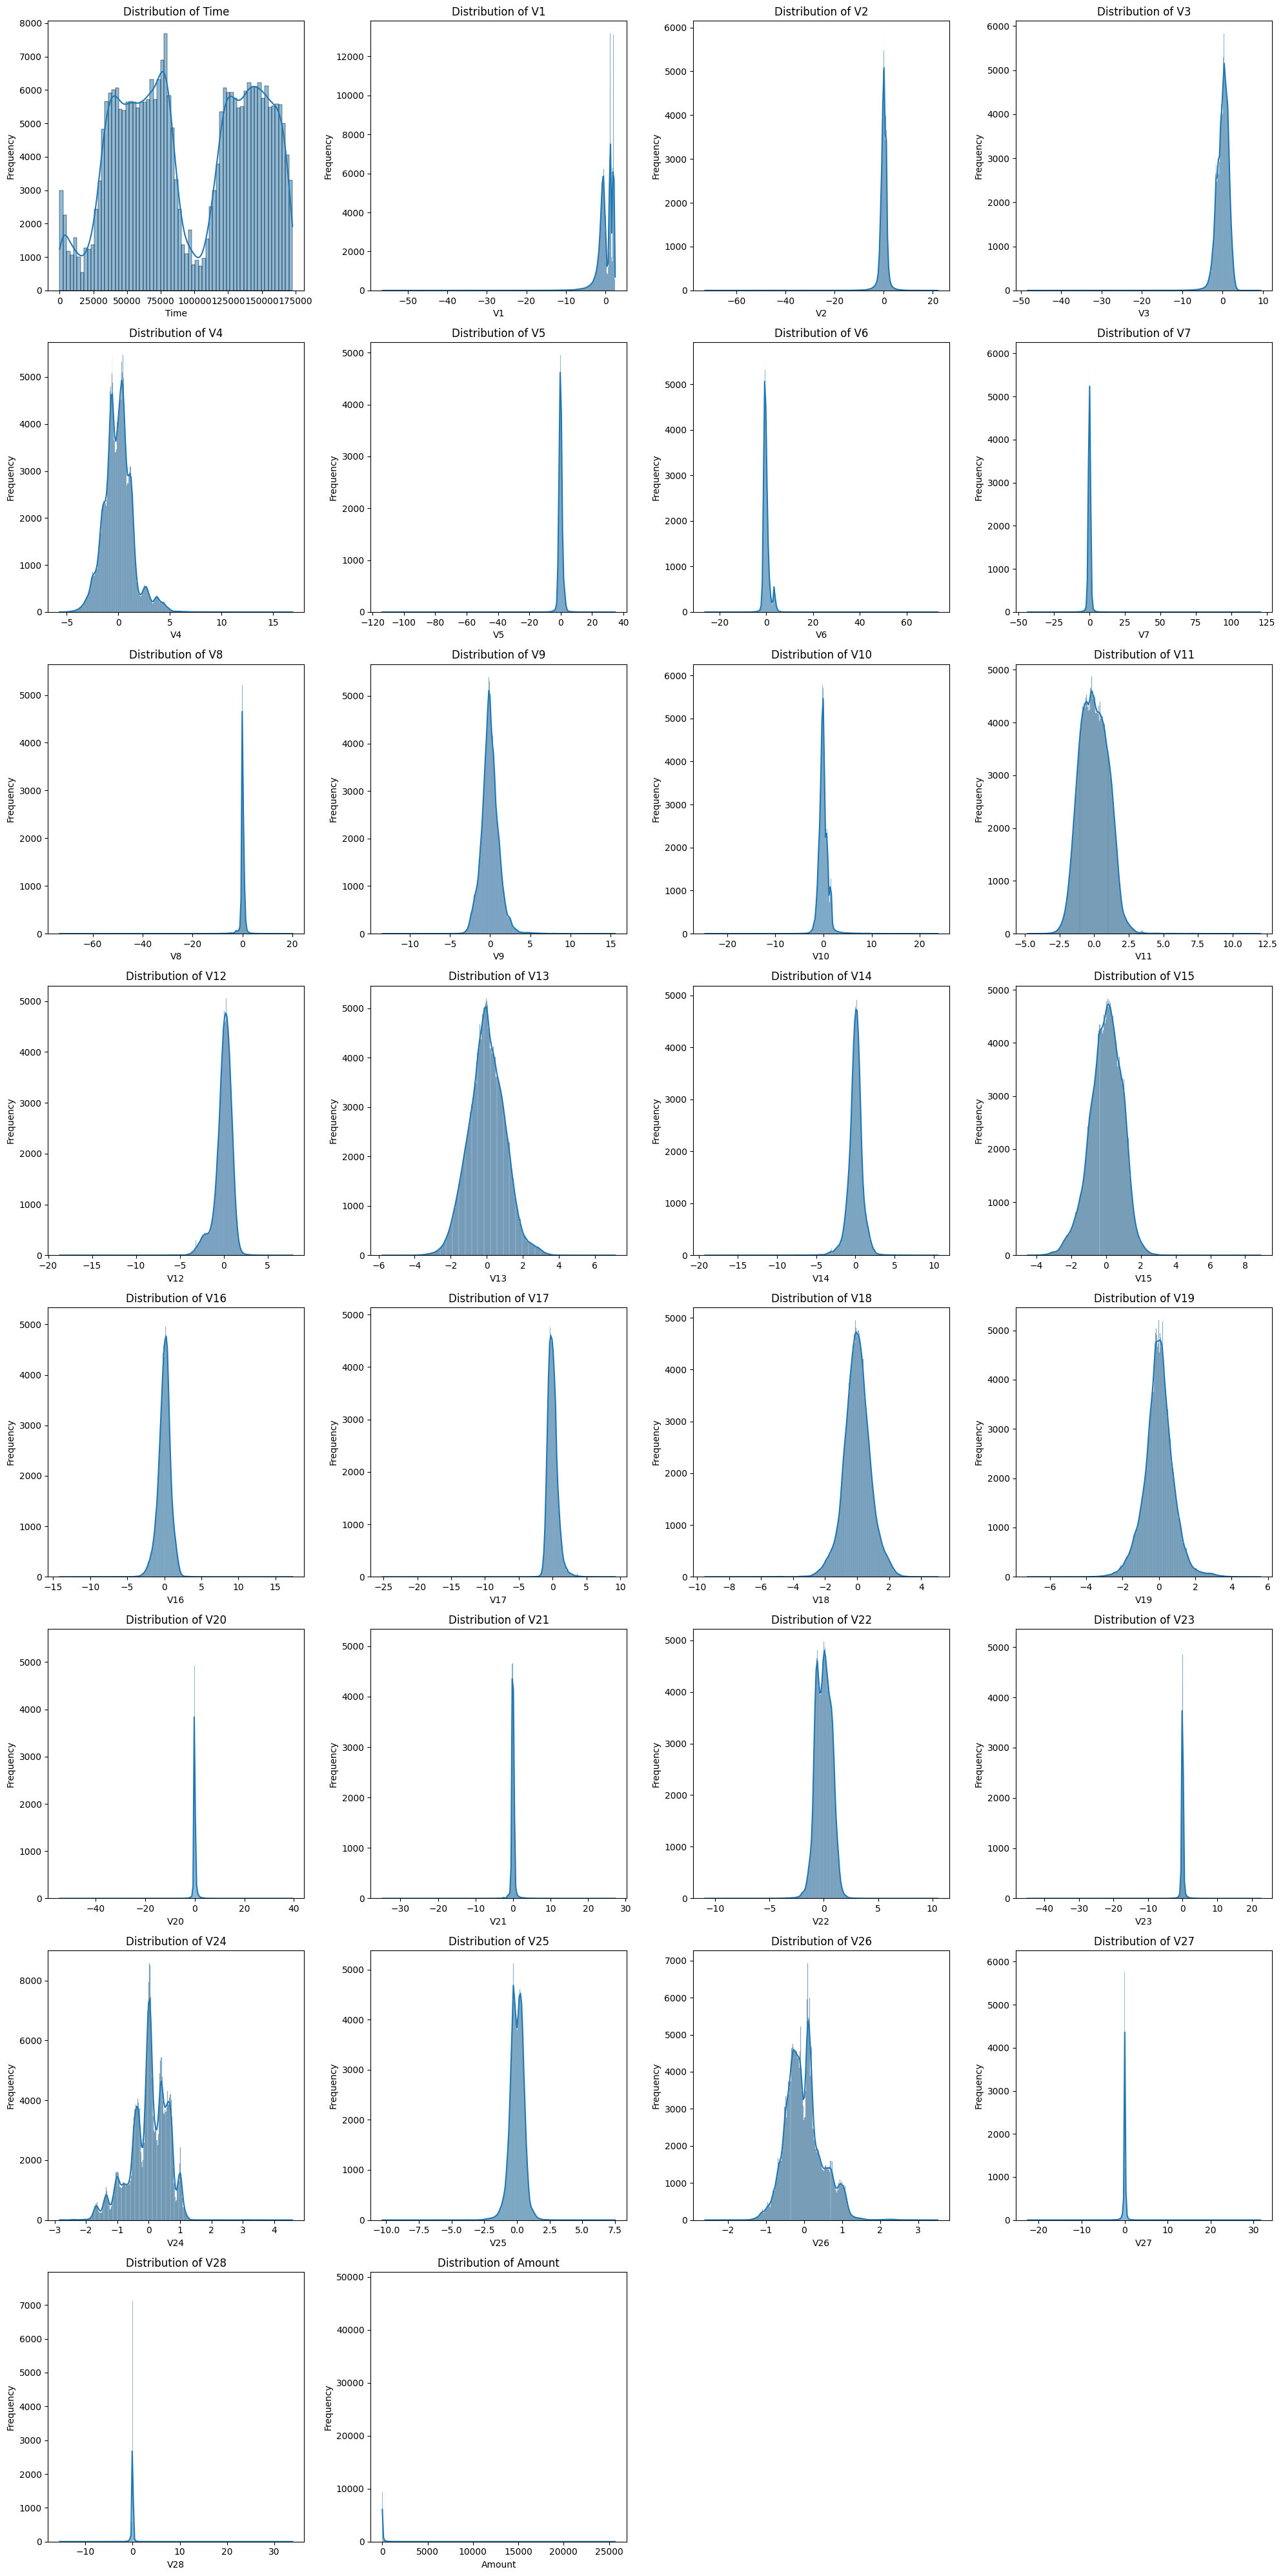

In [10]:
df_numeric = df.drop(columns=['Class'])

n_cols = len(df_numeric.columns)
n_rows = (n_cols + 3) // 4 # To ensure enough rows for 4 columns per row

plt.figure(figsize=(20, 5 * n_rows))

for i, column in enumerate(df_numeric.columns):
    plt.subplot(n_rows, 4, i + 1)
    sns.histplot(df_numeric[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# **correlation representaion**

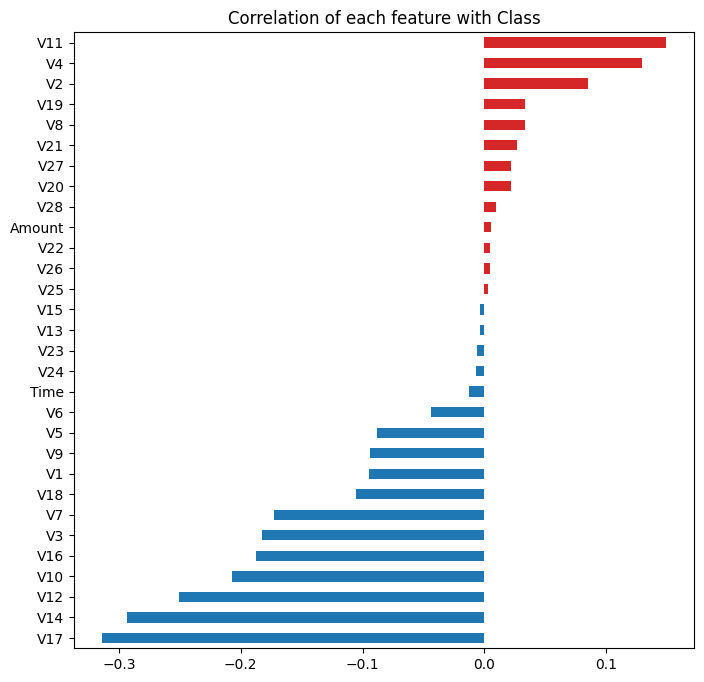

In [11]:
corr = df.corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(8, 8))
corr.plot(kind='barh', color=np.where(corr > 0, 'tab:red', 'tab:blue'))
plt.title('Correlation of each feature with Class')
plt.show()

Amount and Time analysis

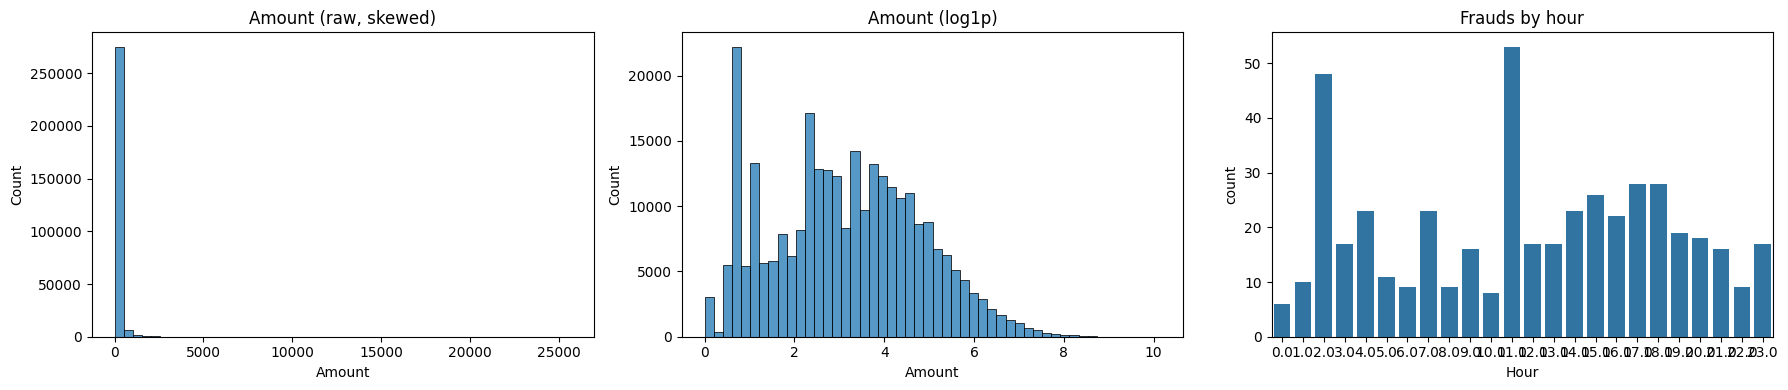

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['Amount'], bins=50, ax=axes[0]).set_title('Amount (raw, skewed)')
sns.histplot(np.log1p(df['Amount']), bins=50, ax=axes[1]).set_title('Amount (log1p)')
df['Hour'] = (df['Time'] // 3600) % 24
sns.countplot(x='Hour', data=df[df['Class'] == 1], ax=axes[2]).set_title('Frauds by hour')
plt.tight_layout()
plt.show()

### Time vs Transaction Amount

The relationship between **time** and **transaction amount** was visualized separately for **fraudulent** and **legitimate** transactions. The two scatter plots are presented side by side to make the differences between the two classes easier to observe.

#### Fraudulent Transactions

The fraudulent transactions are mostly concentrated at **relatively small transaction amounts**, with many observations below **500** and several transactions close to zero. The fraudulent transactions are also distributed across the entire time range, with some noticeable concentrations around **40,000–45,000** and **90,000–95,000** seconds. However, there is no clear overall temporal pattern that separates fraudulent transactions from legitimate ones.

#### Legitimate Transactions

The legitimate transactions are much more numerous, resulting in a much denser scatter plot. Most transactions also have relatively small amounts, but the legitimate class shows a **much wider range of transaction amounts**, including several high-value transactions above **25,000**. The transaction density also varies across the time range, indicating periods of higher and lower transaction activity.

#### Key Observations

* Fraudulent transactions are generally associated with **relatively small transaction amounts**.
* Legitimate transactions have a **wider range of transaction amounts** and include much higher-value transactions.
* Fraudulent transactions occur throughout the observed time period, so **Time alone does not clearly distinguish fraud from legitimate transactions**.
* There is considerable overlap between the two classes in terms of transaction amount, meaning that **Amount alone is not sufficient for fraud detection**.
* The large difference in the number of observations between the two plots also reflects the **severe class imbalance** in the dataset.


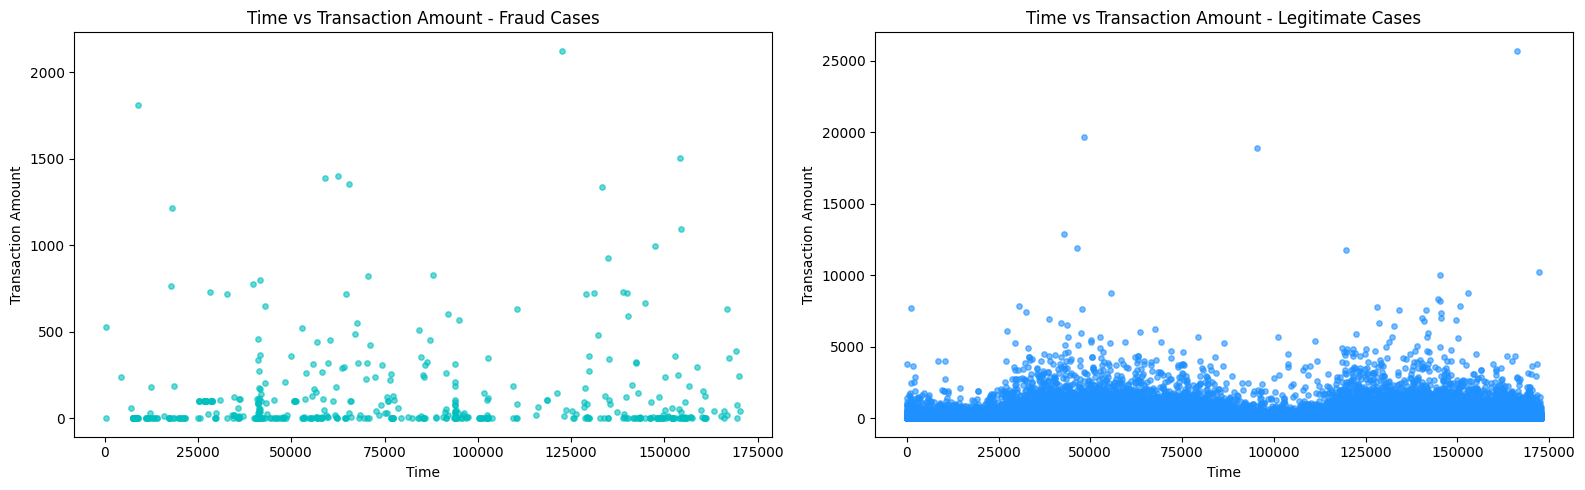

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud cases
axes[0].scatter(
    df[df['Class'] == 1]['Time'],
    df[df['Class'] == 1]['Amount'],
    color="c",
    alpha=0.6,
    s=15
)
axes[0].set_title("Time vs Transaction Amount - Fraud Cases")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Transaction Amount")

# Legitimate cases
axes[1].scatter(
    df[df['Class'] == 0]['Time'],
    df[df['Class'] == 0]['Amount'],
    color="dodgerblue",
    alpha=0.6,
    s=15
)
axes[1].set_title("Time vs Transaction Amount - Legitimate Cases")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

### V14 vs V17 by Class

A scatter plot was created to examine whether **V14** and **V17** can distinguish between legitimate and fraudulent transactions. Due to the severe class imbalance, **10,000 legitimate transactions** were randomly sampled and combined with **all fraudulent transactions** to reduce overplotting and make fraud cases more visible.

#### Observations

* **Legitimate transactions** form a dense cluster around the center, while **fraudulent transactions** are more widely spread.
* Many fraud cases extend toward strongly **negative V14 and V17 values**, particularly in the lower-left region, where they are clearly separated from legitimate transactions.
* Some fraud cases **overlap with legitimate transactions** near the center, showing that these two features alone cannot detect all fraud.
* Fraudulent points also show a noticeable **diagonal pattern**.

#### Key Takeaway

**V14 and V17 appear to be informative features for fraud detection**, but combining them with other features is necessary for better separation. Since legitimate transactions were sampled, the plot **does not represent the actual class proportions**.


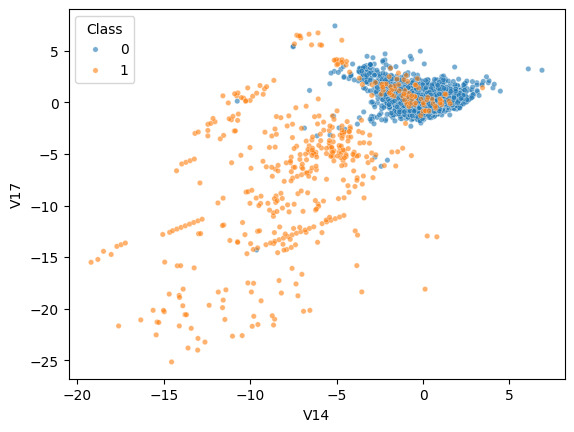

In [14]:
sample = pd.concat([df[df.Class == 0].sample(10000, random_state=42), df[df.Class == 1]])
sns.scatterplot(data=sample, x='V14', y='V17', hue='Class', alpha=0.6, s=15)
plt.show()

### Train-Test Split

The dataset was split into **80% training data** and **20% testing data** using stratified sampling.

* **Training set:** 226,980 transactions with 31 features
* **Testing set:** 56,746 transactions with 31 features

The `stratify=y` parameter was used to maintain the class distribution in both sets, which is important due to the severe class imbalance in the dataset.


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (226980, 31)
X_test: (56746, 31)


### Isolation Forest Results

The **Isolation Forest** model was trained on the training set using a contamination rate of **0.0017**, which represents the estimated fraud rate in the training data.

The model was then applied to the test set. It identified **100 transactions as anomalies**, which were classified as potential fraudulent transactions.

* **Contamination:** 0.0017
* **Test transactions:** 56,746
* **Predicted fraud cases:** 100

The predicted labels were converted from **-1 (anomaly)** and **1 (normal)** into **1 (fraud)** and **0 (legitimate)** for easier evaluation.


In [16]:
from sklearn.ensemble import IsolationForest

fraud_rate_train = y_train.value_counts()[1] / len(y_train)

isolation_forest = IsolationForest(
    random_state=42,
    contamination=fraud_rate_train
)

isolation_forest.fit(X_train)

print("Isolation Forest trained successfully.")
print(f"Contamination: {fraud_rate_train:.4f}")

Isolation Forest trained successfully.
Contamination: 0.0017


In [17]:
test_anomaly_scores = isolation_forest.decision_function(X_test)

# Higher score = more likely to be fraud
test_fraud_scores = -test_anomaly_scores

In [18]:
test_predictions = isolation_forest.predict(X_test)

# -1 = anomaly → fraud (1)
#  1 = normal → normal (0)
y_pred = np.where(test_predictions == -1, 1, 0)

print("Predicted fraud cases:", np.sum(y_pred == 1))

Predicted fraud cases: 100


### Isolation Forest Evaluation

The **Isolation Forest** model was evaluated using the **confusion matrix** and **classification report**.

The model achieved an overall **accuracy of 99.75%**. However, because the dataset is highly imbalanced, accuracy alone is not sufficient to evaluate fraud detection performance.

#### Classification Report

* **Normal transactions:**

  * Precision: **99.88%**
  * Recall: **99.87%**
  * F1-score: **99.88%**

* **Fraudulent transactions:**

  * Precision: **27.00%**
  * Recall: **28.42%**
  * F1-score: **27.69%**

The **Fraud Recall of 28.42%** means that the model successfully detected about **28% of the actual fraudulent transactions**, while the remaining fraudulent transactions were classified as normal.

The **Fraud Precision of 27.00%** means that only about **27% of the transactions predicted as fraud were actually fraudulent**.

#### Class-Specific Detection

The **Normal Detection Rate (Specificity)** was **99.87%**, showing that the model correctly identified most legitimate transactions.

The **Fraud Detection Rate (Recall)** was **28.42%**, indicating that the model has limited ability to detect fraudulent transactions.

#### Key Takeaway

Although Isolation Forest achieves very high performance for **legitimate transactions**, its ability to detect **fraudulent transactions is relatively low**. This highlights the difficulty of detecting fraud in a highly imbalanced dataset and shows why metrics such as **Precision, Recall, and F1-score** are more informative than accuracy alone.


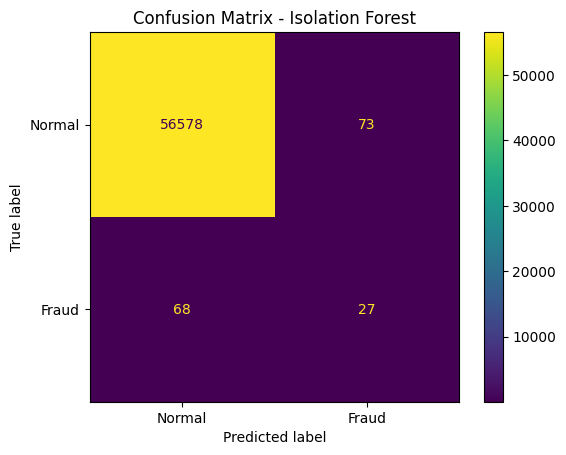

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

disp.plot()
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Normal', 'Fraud'],
        digits=4
    )
)

              precision    recall  f1-score   support

      Normal     0.9988    0.9987    0.9988     56651
       Fraud     0.2700    0.2842    0.2769        95

    accuracy                         0.9975     56746
   macro avg     0.6344    0.6415    0.6378     56746
weighted avg     0.9976    0.9975    0.9975     56746



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

legit_accuracy = TN / (TN + FP)
fraud_accuracy = TP / (TP + FN)

print(f"Accuracy in Detecting Legit Cases: {legit_accuracy}")
print(f"Accuracy in Detecting Fraud Cases: {fraud_accuracy}")


Accuracy in Detecting Legit Cases: 0.998711408448218
Accuracy in Detecting Fraud Cases: 0.28421052631578947


### ROC-AUC and PR-AUC Evaluation

To evaluate the ability of the Isolation Forest to **rank fraudulent transactions as more anomalous**, both **ROC-AUC** and **PR-AUC** were calculated using the anomaly scores.

#### Results

| Metric      |  Train |   Test |
| ----------- | -----: | -----: |
| **PR-AUC**  | 0.1871 | 0.1435 |
| **ROC-AUC** | 0.9490 | 0.9342 |

### ROC-AUC

The model achieved a **ROC-AUC of 0.9490 on the training set** and **0.9342 on the test set**.

The small difference between the training and test scores indicates that the model maintains similar ranking performance on unseen data. This suggests that there is **no clear evidence of overfitting**.

The test ROC-AUC of **0.9342** indicates that the anomaly scores provide strong separation between fraudulent and legitimate transactions in terms of ranking.

### PR-AUC

The **PR-AUC** was **0.1871 on the training set** and **0.1435 on the test set**.

The decrease from train to test is expected because the test set contains unseen transactions. More importantly, the difference is not large enough by itself to indicate severe overfitting.

PR-AUC is particularly important for this problem because the dataset is **highly imbalanced** and focuses directly on the model's ability to identify the minority **fraud class**.

### Overfitting Analysis

There is **no clear evidence of overfitting** based on these results.

The ROC-AUC decreased only from **0.9490 to 0.9342**, a difference of about **0.0148** between training and testing. This relatively small gap indicates that the model's ability to rank anomalous transactions remains strong on unseen data.

Similarly, the PR-AUC decreased from **0.1871 to 0.1435**. Although there is a larger drop compared with ROC-AUC, the test score still shows that the anomaly scores contain useful information for identifying fraudulent transactions.

Therefore, the Isolation Forest shows **reasonable generalization**, although its threshold-based fraud detection performance remains limited, as reflected by the relatively low **Fraud Recall (28.42%)**.

### Key Takeaway

The Isolation Forest demonstrates **strong ranking performance and reasonable generalization**, with similar ROC-AUC values on the training and test sets. However, its relatively low PR-AUC and Fraud Recall show that identifying the actual fraudulent transactions remains challenging due to the severe class imbalance.


In [22]:
train_anomaly_scores = isolation_forest.decision_function(X_train)
test_anomaly_scores = isolation_forest.decision_function(X_test)

# Higher score = more likely fraud
train_fraud_scores = -train_anomaly_scores
test_fraud_scores = -test_anomaly_scores

In [23]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score

train_pr_auc = average_precision_score(
    y_train,
    train_fraud_scores
)

test_pr_auc = average_precision_score(
    y_test,
    test_fraud_scores
)

print(f"Train PR-AUC: {train_pr_auc:.4f}")
print(f"Test PR-AUC:  {test_pr_auc:.4f}")


train_roc_auc = roc_auc_score(
    y_train,
    train_fraud_scores
)

test_roc_auc = roc_auc_score(
    y_test,
    test_fraud_scores
)

print(f"Train ROC-AUC: {train_roc_auc:.4f}")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")

Train PR-AUC: 0.1871
Test PR-AUC:  0.1435
Train ROC-AUC: 0.9490
Test ROC-AUC:  0.9342


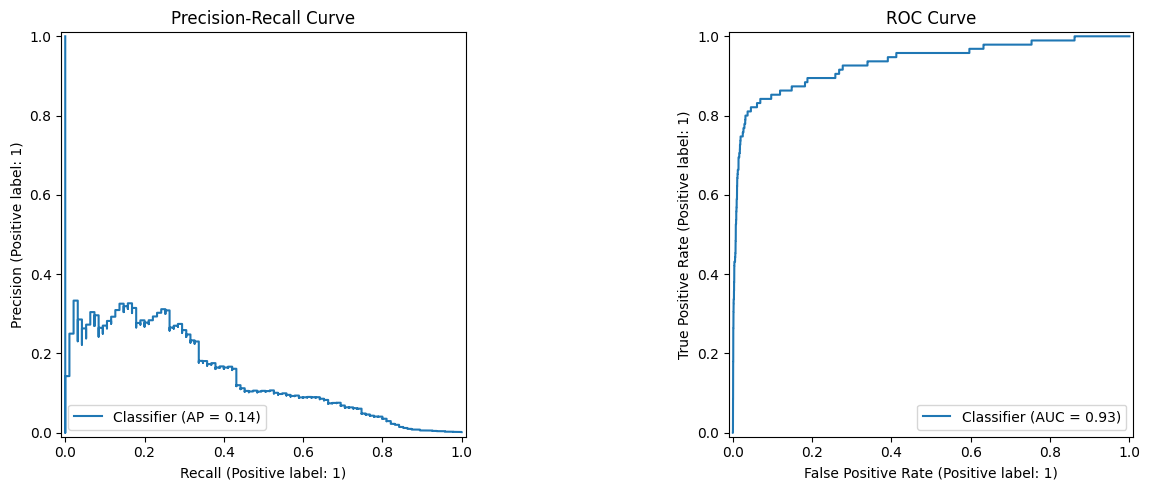

In [24]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_fraud_scores,
    ax=axes[0]
)
axes[0].set_title('Precision-Recall Curve')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    test_fraud_scores,
    ax=axes[1]
)
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

### Isolation Forest Hyperparameter Tuning

To improve the performance of the Isolation Forest model, **Randomized Search** was used to explore different combinations of hyperparameters.

The training data was further divided into a **training subset and validation set**, while the original test set was kept separate for the final evaluation.

The following hyperparameters were tuned:

* **`n_estimators`**: Number of isolation trees.
* **`max_samples`**: Number or proportion of samples used to build each tree.
* **`max_features`**: Number or proportion of features considered by each tree.
* **`bootstrap`**: Determines whether samples are drawn with replacement.

A total of **20 random combinations** were tested, and **PR-AUC** was used as the selection metric because the dataset is highly imbalanced and fraud detection is the main objective.

### Best Hyperparameters

The best configuration achieved a **validation PR-AUC of 0.3201**:

| Hyperparameter        | Best Value |
| --------------------- | ---------: |
| `n_estimators`        |        100 |
| `max_samples`         |        0.8 |
| `max_features`        |        0.6 |
| `bootstrap`           |       True |
| **Validation PR-AUC** | **0.3201** |

### Final Model Evaluation

The model was retrained using the selected hyperparameters and evaluated on the unseen test set.

| Metric                | Result |
| --------------------- | -----: |
| Accuracy              | 99.74% |
| Normal Detection Rate | 99.87% |
| Fraud Precision       | 21.65% |
| Fraud Recall          | 22.11% |
| Fraud F1-score        | 21.88% |
| PR-AUC                | 0.1775 |
| ROC-AUC               | 0.9320 |

### Fraud Detection Performance

The model achieved a **Fraud Recall of 22.11%**, meaning that it successfully detected approximately **22% of the actual fraudulent transactions** in the test set.

The **Fraud Precision of 21.65%** means that approximately 22% of the transactions predicted as fraudulent were actually fraudulent.

The **Normal Detection Rate was 99.87%**, showing that the model correctly classified most legitimate transactions.

### Key Takeaway

Although the tuned model maintains a high **ROC-AUC of 0.9320**, its threshold-based fraud detection performance remains limited, with a **Fraud Recall of 22.11%** and **PR-AUC of 0.1775**.

This shows that Isolation Forest can assign useful anomaly scores for ranking transactions, but identifying fraudulent transactions accurately remains challenging because of the **severe class imbalance** in the dataset.

The model was selected using the validation set and then evaluated on the **unseen test set**, providing a more reliable estimate of its generalization performance.


### Justification of the Selected Parameters

The selected hyperparameters were chosen based on the **highest validation PR-AUC** obtained during Randomized Search, since PR-AUC is particularly suitable for this highly imbalanced fraud detection problem.

The selected configuration was:

* **`n_estimators = 100`**
  The best validation result was obtained using 100 trees. Increasing the number of trees did not produce a higher PR-AUC among the tested combinations. Therefore, 100 trees provided the best validation performance while keeping the model relatively efficient.

* **`max_samples = 0.8`**
  Using **80% of the training samples for each tree** gave the highest validation PR-AUC among the tested combinations. This allows each tree to be built from a large but slightly different subset of the data, increasing the diversity of the isolation trees.

* **`max_features = 0.6`**
  Using **60% of the features for each tree** produced the highest validation PR-AUC in the selected combination. Considering a subset of features introduces additional randomness and allows different trees to isolate observations using different feature combinations.

* **`bootstrap = True`**
  Sampling with replacement was part of the best-performing combination. This introduces additional variation between the trees and, for this dataset, resulted in the highest validation PR-AUC.

### Overall Selection

The final combination:

**`n_estimators=100, max_samples=0.8, max_features=0.6, bootstrap=True`**

achieved the **highest validation PR-AUC of 0.3201** among the 20 randomly tested configurations. Therefore, these parameters were selected for training the final Isolation Forest model.


In [25]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score
from sklearn.model_selection import ParameterSampler

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


param_distributions = {
    'n_estimators': [100, 200, 300, 500, 600, 700],
    'max_samples': ['auto', 0.5,0.6, 0.8, 1.0],
    'max_features': [0.5,0.6, 0.8, 1.0],
    'bootstrap': [False, True]
}


random_combinations = list(
    ParameterSampler(
        param_distributions,
        n_iter=20,
        random_state=42
    )
)

results = []

for params in random_combinations:

    model = IsolationForest(
        random_state=42,
        contamination=fraud_rate_train,
        **params
    )

    model.fit(X_train_sub)

    val_scores = -model.decision_function(X_val)

    pr_auc = average_precision_score(
        y_val,
        val_scores
    )

    results.append({
        **params,
        'PR_AUC': pr_auc
    })

In [26]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'PR_AUC',
    ascending=False
)

results_df.head()

,n_estimators,max_samples,max_features,bootstrap,PR_AUC
13,100,0.8,0.6,True,0.320131
7,300,1.0,0.8,False,0.314709
1,100,0.5,0.5,False,0.309764
4,300,0.6,1.0,False,0.302752
12,100,1.0,1.0,False,0.296106


In [27]:
best_params = results_df.iloc[0].drop('PR_AUC').to_dict()

print("Best Parameters:")
print(best_params)

print("\nBest Validation PR-AUC:")
print(results_df.iloc[0]['PR_AUC'])

Best Parameters:
{'n_estimators': 100, 'max_samples': 0.8, 'max_features': 0.6, 'bootstrap': True}

Best Validation PR-AUC:
0.32013078758780705


In [28]:
best_model = IsolationForest(
    random_state=42,
    contamination=fraud_rate_train,
    **best_params
)

best_model.fit(X_train)

IsolationForest(bootstrap=True, contamination=np.float64(0.0016653449643140364),
                max_features=0.6, max_samples=0.8, random_state=42)

In [29]:
import joblib

# Save the FINAL (tuned) Isolation Forest = best_model, plus the exact feature columns
# it was trained on (Time, V1..V28, Amount, Hour). The Streamlit app loads these files.
joblib.dump(best_model, 'isolation_forest_model.pkl')
joblib.dump(list(X_train.columns), 'model_features.pkl')

print('Saved: isolation_forest_model.pkl  (final tuned model = best_model)')
print('Saved: model_features.pkl ->', list(X_train.columns))


Saved: isolation_forest_model.pkl  (final tuned model = best_model)
Saved: model_features.pkl -> ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour']


In [30]:
test_predictions = best_model.predict(X_test)

y_pred = np.where(test_predictions == -1, 1, 0)

test_fraud_scores = -best_model.decision_function(X_test)

In [31]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    roc_auc_score
)

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Normal', 'Fraud'],
        digits=4
    )
)

# PR-AUC
pr_auc = average_precision_score(
    y_test,
    test_fraud_scores
)

# ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    test_fraud_scores
)

print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9987    0.9987    0.9987     56651
       Fraud     0.2165    0.2211    0.2188        95

    accuracy                         0.9974     56746
   macro avg     0.6076    0.6099    0.6087     56746
weighted avg     0.9974    0.9974    0.9974     56746

PR-AUC:  0.1775
ROC-AUC: 0.9320


In [32]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

legit_detection = TN / (TN + FP)
fraud_detection = TP / (TP + FN)

print(f"Accuracy in Detecting Legit Cases: {legit_detection:.2%}")
print(f"Accuracy in Detecting Fraud Cases: {fraud_detection:.2%}")

Accuracy in Detecting Legit Cases: 99.87%
Accuracy in Detecting Fraud Cases: 22.11%


### Comparison Before and After Hyperparameter Tuning

The performance of the Isolation Forest model was compared **before and after hyperparameter tuning**.

| Metric                    | Before Tuning | After Tuning |    Change |
| ------------------------- | ------------: | -----------: | --------: |
| **Normal Detection Rate** |        99.87% |       99.87% |       ≈ 0 |
| **Fraud Precision**       |        27.00% |       21.65% | ↓ 5.35 pp |
| **Fraud Recall**          |        28.42% |       22.11% | ↓ 6.31 pp |
| **Fraud F1-score**        |        27.69% |       21.88% | ↓ 5.81 pp |
| **PR-AUC**                |        0.1435 |       0.1775 |  ↑ 0.0340 |
| **ROC-AUC**               |        0.9342 |       0.9320 |  ↓ 0.0022 |
| **Accuracy**              |        99.75% |       99.74% |       ≈ 0 |

### Comparison of the Results

After tuning, the **PR-AUC increased from 0.1435 to 0.1775**, indicating an improvement in the overall Precision-Recall ranking performance on the unseen test set.

The **ROC-AUC remained almost unchanged**, decreasing slightly from **0.9342 to 0.9320**. This indicates that the model's overall ability to rank fraudulent transactions above legitimate ones remained very similar.

However, the threshold-based classification performance decreased:

* Fraud Recall decreased from **28.42% to 22.11%**.
* Fraud Precision decreased from **27.00% to 21.65%**.
* Fraud F1-score decreased from **27.69% to 21.88%**.

The **Normal Detection Rate remained almost identical at 99.87%**.

### Key Observation

The tuning process did **not improve the final classification metrics**, but it did improve the **PR-AUC**, which was the metric used to select the best hyperparameters.

This shows an important difference between **ranking performance** and **threshold-based classification performance**. A model can produce better anomaly scores overall while still detecting fewer fraud cases at the default Isolation Forest prediction threshold.

Therefore, the tuned model provides better **PR-AUC performance**, but its final fraud detection recall at the default threshold is lower than the original model.


## Feature Importance Using Permutation Importance

Since **Isolation Forest** does not provide a direct `feature_importances_` attribute like **Random Forest** or **XGBoost**, **Permutation Importance** was used as an alternative method to estimate the importance of each feature.

### Why Permutation Importance?

Permutation Importance measures how much the model's performance changes when the values of one feature are randomly shuffled.

The main idea is:

1. Evaluate the model using the original data.
2. Randomly shuffle one feature while keeping all other features unchanged.
3. Evaluate the model again.
4. Measure the change in the evaluation score.

If shuffling a feature causes a large decrease in the model's performance, this indicates that the feature was important for the model's predictions.

In this project, **PR-AUC** was used as the scoring metric because the dataset is highly imbalanced and PR-AUC is more informative for evaluating fraud detection performance than accuracy.

The anomaly scores produced by Isolation Forest were converted using:

`-decision_function(X)`

because Isolation Forest assigns lower decision-function values to more anomalous observations. Negating the scores makes higher values correspond to a higher likelihood of fraud, which allows them to be used with PR-AUC.

### Interpretation

The resulting importance values represent the change in **PR-AUC** after permuting each feature.

* **Higher positive importance:** The feature contributes to the model's ability to rank fraudulent transactions above legitimate ones.
* **Importance close to zero:** Permuting the feature has little effect on model performance.
* **Negative importance:** The model performed slightly better after the feature was shuffled. This can happen because of sampling variability, feature interactions, or noise.

The top features obtained were:

* **V17**
* **V14**
* **V12**
* **V3**
* **V10**
* **V16**
* **V18**
* **V4**
* **V11**
* **Hour**

Among them, **V17** had the highest permutation importance, followed by **V14** and **V12**, indicating that these features had the largest impact on the PR-AUC of the Isolation Forest model when their values were randomly permuted.

The `Std` column represents the standard deviation of the importance across the **5 permutations** (`n_repeats=5`). A smaller standard deviation indicates that the measured importance was more consistent across the repeated permutations.

### Key Point

Permutation Importance does not change the Isolation Forest model or perform feature selection. It is an **interpretation technique** used after training to estimate how much each feature contributes to the model's predictive performance.


In [33]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score

def pr_auc_scorer(model, X, y):
    scores = -model.decision_function(X)
    return average_precision_score(y, scores)

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring=pr_auc_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)


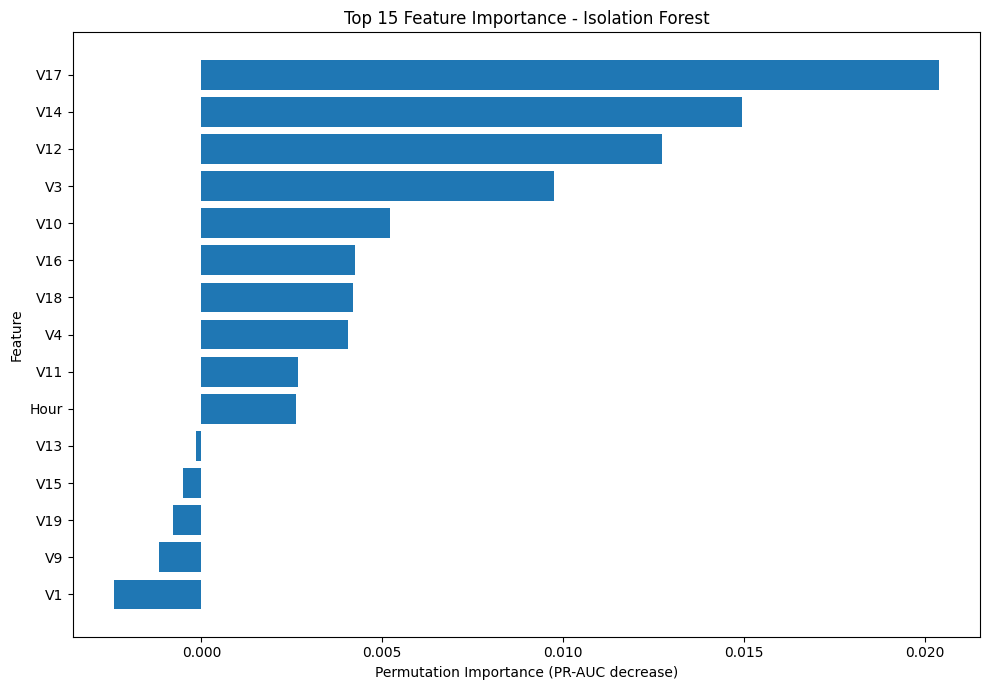

In [34]:
top_features = feature_importance.head(15).sort_values('Importance')

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Permutation Importance (PR-AUC decrease)')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance - Isolation Forest')

plt.tight_layout()
plt.show()

## SHAP Feature Importance

### What SHAP Does

Since the Isolation Forest model does not provide a direct feature importance measure, **SHAP (SHapley Additive exPlanations)** can be used as an additional model interpretation technique.

SHAP explains the contribution of each feature to the model's output for individual observations.

In this analysis:

* A random sample of **2,000 transactions** was selected from the test set to reduce the computational cost of SHAP.
* A **TreeExplainer** was used because Isolation Forest is a tree-based model.
* SHAP values were calculated to estimate the contribution of each feature to the model output.
* The **mean absolute SHAP value** was then used to summarize the overall importance of each feature.

### How to Read the Plot

The SHAP bar plot shows the average magnitude of each feature's contribution:

* **Y-axis:** Features, ordered from the most to the least influential.
* **X-axis:** `mean(|SHAP value|)`, representing the average magnitude of the feature's contribution.
* A **larger SHAP value** means that the feature has a greater influence on the model output.
* Because absolute SHAP values are used, the bar plot shows **importance only**, not whether the feature increases or decreases the anomaly score.

### Key Findings

The SHAP analysis indicates that **Hour** has the largest average impact on the model output, followed by **Time**.

Among the anonymized PCA features, **V26, V13, V19, V11, and V15** show relatively high importance.

**Amount** has a comparatively smaller contribution among the features shown.

This suggests that the model's output is influenced substantially by **time-related information**, together with several anonymized PCA components.

### Important Note

The bar plot shows **how strongly each feature influences the model output, but not the direction of its influence**.

To investigate whether high or low values of a feature push the prediction toward a more anomalous or less anomalous result, a SHAP summary plot with individual SHAP values can be used.

Therefore:

**SHAP bar plot → Which features are important?**

**SHAP summary plot → Which feature values push the prediction in which direction?**


In [35]:
import shap

X_shap = X_test.sample(
    n=2000,
    random_state=42
)

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_shap)

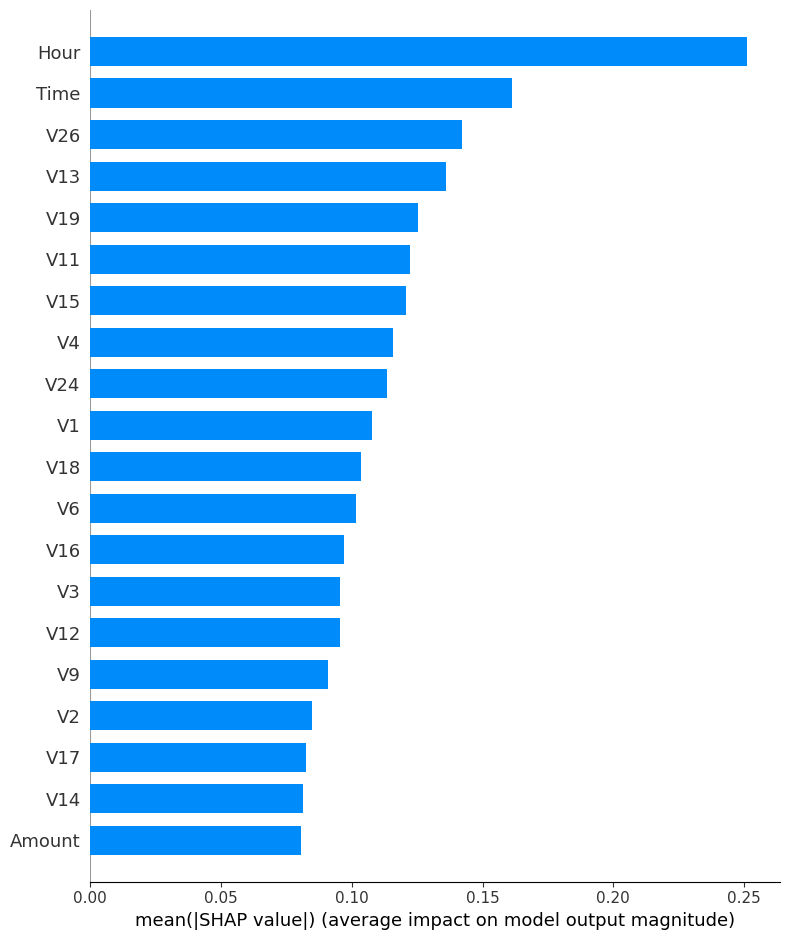

In [36]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

## SHAP Summary Plot (Beeswarm)

### What the Plot Shows

The **SHAP Summary Plot (Beeswarm)** provides a more detailed view of the model's feature contributions compared with the SHAP bar plot.

The plot uses the SHAP values calculated from the **2,000-row sample** and represents each point as one transaction for a specific feature.

Unlike the bar plot, the beeswarm plot shows both the **magnitude and direction** of each feature's contribution to the model output.

### How to Read the Plot

* **Y-axis:** Features, ordered by their overall importance.
* **X-axis:** SHAP value, representing the contribution of a feature to the model output.

  * Values to the **right of zero** indicate a positive contribution to the model output.
  * Values to the **left of zero** indicate a negative contribution.
  * Values close to **zero** indicate little contribution.
* **Color:** Represents the actual feature value.

  * **Red:** High feature values.
  * **Blue:** Low feature values.
* **Spread:** A wider horizontal spread indicates that the feature can have a stronger and more variable impact on the model output.

### Key Findings

* **Hour** and **Time** show relatively large SHAP spreads, indicating that they have a strong influence on the model output.
* For **V13, V11, V19**, and several other anonymized features, higher feature values generally appear more frequently on the negative SHAP side, while lower values tend to appear closer to zero or on the positive side.
* **V1** has a dense concentration of high-value observations around zero and slightly negative SHAP values, suggesting a relatively small negative contribution for many observations.
* **Amount** has one of the smallest spreads, indicating a comparatively limited contribution to the model output.
* Many features have observations concentrated around zero with a smaller number of points extending toward more extreme SHAP values. This indicates that their effect is usually limited but can become substantial for certain transactions.

### Important Note

SHAP values describe the **association between feature values and the model output**; they do not establish a causal relationship.

Also, **V1–V28 are anonymized PCA-transformed features**, so their SHAP patterns can be interpreted in terms of their contribution to the model, but their original real-world meaning is not available.

### Key Difference from the SHAP Bar Plot

The **SHAP bar plot** answers:

> **Which features are generally the most important?**

The **SHAP beeswarm plot** answers:

> **Which features are important, and how do their values affect the model output?**


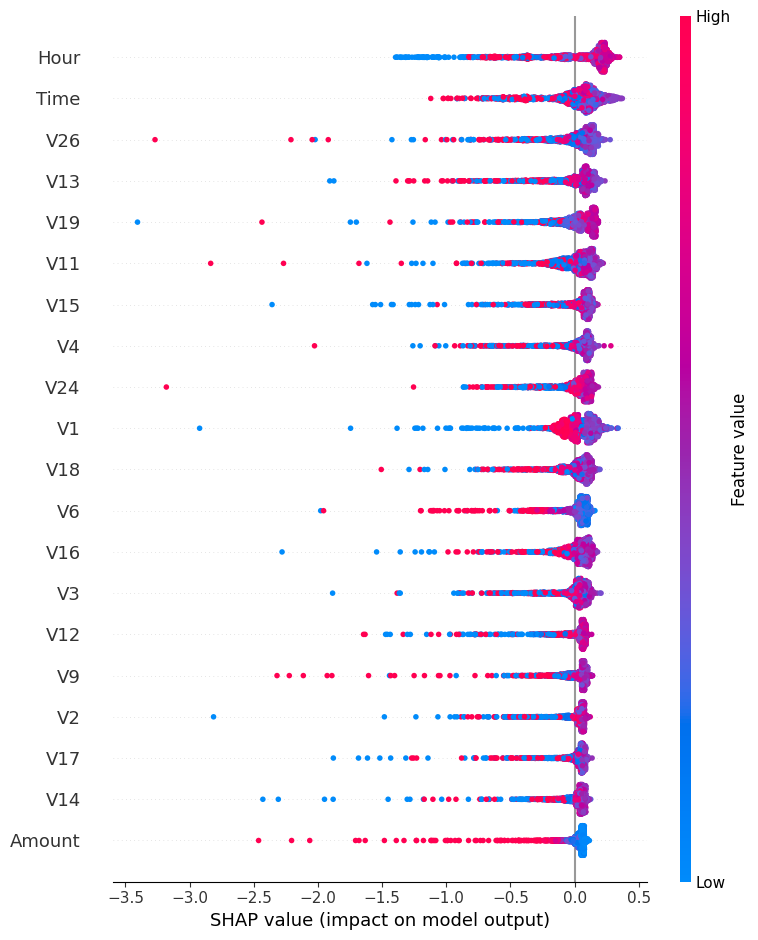

In [37]:
shap.summary_plot(
    shap_values,
    X_shap
)

## SHAP Force Plot (Single Transaction)

### What the Plot Shows

The **SHAP Force Plot** provides a local explanation for a single transaction.

In this analysis, transaction at `transaction_index = 0` was selected to understand how the different features contributed to the model's output for this specific observation.

The explanation starts from the model's **expected value**, which represents the base output of the model. Each feature then pushes the output either higher or lower until the final prediction is reached.

`matplotlib=True` was used to display the force plot as a static image.

### How to Read the Plot

* **Base value (`expected_value`):** The starting point before considering the individual transaction's feature values.
* **`f(x)`:** The final model output for this transaction, which is approximately **35.07**.
* **Red features:** Push the model output higher.
* **Blue features:** Push the model output lower.
* **Block width:** Represents the magnitude of the feature's contribution. A wider block indicates a larger contribution.
* The value shown next to each feature represents its actual value for this transaction, such as `Hour = 17.0`.

### Key Findings

For this transaction:

* The main features contributing positively to the model output include **V19, V11, and Hour**.
* The main features contributing negatively include **V24, V16, V17, and V15**.
* The positive and negative contributions are relatively similar in magnitude, causing them to partially cancel each other.
* As a result, the final output remains relatively close to the model's base value, around **35.1**.

### Interpretation

The force plot shows **how the individual feature values of this specific transaction combine to produce its model output**.

It is therefore a **local explanation**, rather than a measure of overall feature importance.

The SHAP analyses can be viewed at three levels:

| SHAP Plot         | Purpose                                                            |
| ----------------- | ------------------------------------------------------------------ |
| **Bar Plot**      | Shows overall feature importance                                   |
| **Beeswarm Plot** | Shows importance and direction across many transactions            |
| **Force Plot**    | Explains the contribution of features for one specific transaction |

### Important Note

The value shown by `f(x)` is the model's **raw output on the scale being explained**, not a probability of fraud.

Therefore, a value such as **35.07 should not be interpreted as a 35.07% probability of fraud**.

The force plot explains only the selected transaction, while the bar and beeswarm plots provide broader information about the model's behavior.


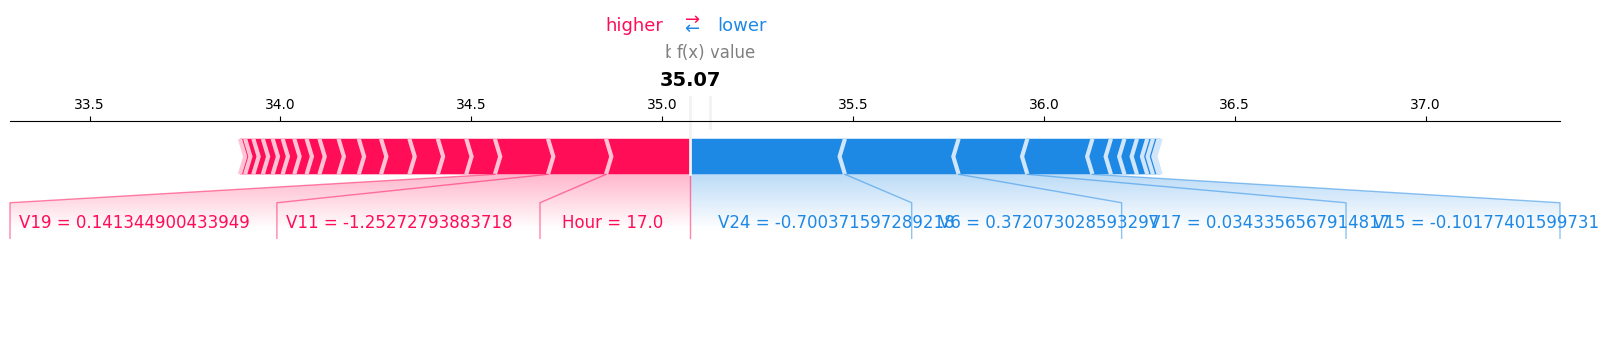

In [38]:
transaction_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[transaction_index],
    X_test.iloc[transaction_index],
    matplotlib=True
)

## Autoencoder for Anomaly Detection

### Why Use an Autoencoder?

An **Autoencoder** is a Deep Learning model that can be used for **Anomaly Detection**.

Unlike a supervised classifier, the Autoencoder does not need to learn the difference between fraud and legitimate transactions. Instead, it is trained only on **legitimate transactions** and learns how normal transactions are represented.

The main idea is:

> If the model learns normal transactions well, it should reconstruct normal transactions with a small error. Fraudulent or unusual transactions are expected to have a larger reconstruction error.

---

## How the Autoencoder Works

An Autoencoder consists of two main parts:

### 1. Encoder

The **Encoder** takes the original input and gradually compresses it into a smaller representation called the **latent representation** or **bottleneck**.

In our model, the input contains **31 features**:

**31 → 32 → 16**

The first Dense layer maps the 31 input features to 32 neurons, and the second layer compresses them further to only 16 neurons.

The 16-dimensional representation is the **bottleneck** of the network.

The purpose of this compression is to force the model to learn the most useful patterns that represent normal transactions.

### 2. Decoder

The **Decoder** takes the compressed representation and tries to reconstruct the original input.

Our decoder follows:

**16 → 32 → 31**

The final layer contains 31 neurons, matching the original number of input features.

Therefore, the complete architecture is:

**Input (31) → 32 → 16 → 32 → Output (31)**

The output should be as close as possible to the original input.

---

## Why Is the Bottleneck Important?

The bottleneck prevents the network from simply memorizing the input.

The model has to compress the original 31 features into only 16 values and then reconstruct the original transaction from this compressed representation.

During training on legitimate transactions, the network learns the patterns that are common in normal transactions.

When an unusual transaction is given to the trained Autoencoder, its pattern may not be represented well by the learned normal patterns. As a result, the reconstructed transaction can differ more from the original one.

This difference is measured using the **Reconstruction Error**.

---

## Data Preparation

Only legitimate transactions from the training set were used to train the Autoencoder:

`X_train_normal = X_train[y_train == 0]`

This is important because we want the model to learn the structure of **normal transactions** without directly learning the fraud examples.

### Feature Scaling

`StandardScaler` was applied before training the neural network.

Scaling is important for an Autoencoder because the network uses numerical optimization to minimize the reconstruction loss. If features have very different scales, features with larger numerical ranges can dominate the loss.

The scaler was fitted only on the normal training data and then applied to the test data.

---

## Autoencoder Architecture

The model uses the following layers:

| Layer          | Output Size | Purpose                                             |
| -------------- | ----------: | --------------------------------------------------- |
| Input          |          31 | Original transaction features                       |
| Dense + ReLU   |          32 | Learns a higher-level representation                |
| Dense + ReLU   |          16 | Compresses the input into the latent representation |
| Dense + ReLU   |          32 | Expands the latent representation                   |
| Dense + Linear |          31 | Reconstructs the original input                     |

The network contains **3,119 trainable parameters**.

### Activation Functions

The hidden layers use **ReLU** activation:

`ReLU(x) = max(0, x)`

ReLU introduces non-linearity, allowing the network to learn more complex relationships between the features.

The final layer uses a **linear activation** because the goal is to reconstruct continuous numerical values rather than produce a class probability.

---

## Training the Autoencoder

The Autoencoder was trained using:

* **Optimizer:** Adam
* **Loss function:** Mean Squared Error (MSE)
* **Epochs:** 30
* **Batch size:** 256
* **Validation split:** 10%
* **Training data:** Legitimate transactions only

The model receives the same data as both the input and the target:

**Input → Autoencoder → Reconstructed Input**

Therefore, it learns to minimize the difference between the original transaction and its reconstruction.

### Training Behavior

The training loss decreased from approximately **0.519** in the first epoch to **0.068** by the final epoch.

The validation loss also decreased from approximately **0.317** to **0.065**.

This indicates that the Autoencoder successfully learned to reconstruct the normal training data, with the loss generally decreasing throughout training.

---

## Reconstruction Error

After training, the Autoencoder reconstructs each test transaction.

The **reconstruction error** is calculated as the average squared difference between the original scaled transaction and its reconstructed version.

A low reconstruction error means that the transaction is similar to the patterns learned from normal transactions.

A high reconstruction error means that the transaction is harder for the Autoencoder to reconstruct and may therefore be anomalous.

In this project:

**Low Reconstruction Error → More likely Normal**

**High Reconstruction Error → More likely Anomalous**

---

## Choosing the Anomaly Threshold

A threshold is required to convert the continuous reconstruction error into a binary prediction.

The threshold was calculated using the **95th percentile of the reconstruction errors of the normal training transactions**.

The resulting threshold was:

**Threshold = 0.2133**

This means that approximately 95% of the normal training transactions have reconstruction errors below this value.

Therefore:

* Reconstruction Error ≤ **0.2133** → Normal (`0`)
* Reconstruction Error > **0.2133** → Anomaly/Fraud (`1`)

This threshold was determined using only the normal training data, rather than using the test labels.

---

## Evaluation Results

The Autoencoder achieved the following results on the unseen test set:

| Metric           | Result |
| ---------------- | -----: |
| Normal Precision |   1.00 |
| Normal Recall    |   0.95 |
| Fraud Precision  |   0.03 |
| Fraud Recall     |   0.82 |
| Fraud F1-score   |   0.05 |
| Accuracy         |   0.95 |
| ROC-AUC          | 0.8992 |
| PR-AUC           | 0.6347 |

### Interpretation

The Autoencoder detected **82% of the fraudulent transactions**, giving it a relatively high fraud recall.

However, its **fraud precision was only 3%**. This means that although the model identified many fraudulent transactions, it also classified a large number of legitimate transactions as anomalies.

This is reflected in the relatively low overall accuracy of **95%** compared with the extremely high accuracy that can be obtained by simply favoring the majority class.

Because the dataset is highly imbalanced, **PR-AUC, fraud recall, and fraud precision** are more informative than accuracy alone.

The **PR-AUC of 0.6347** indicates that the reconstruction-error scores provide useful separation between fraudulent and legitimate transactions for ranking purposes.

---

## Reconstruction Error Distribution

The histogram compares the reconstruction-error distributions of legitimate and fraudulent transactions.

The vertical dashed line represents the selected anomaly threshold (**0.2133**).

Transactions to the right of this threshold are classified as anomalies.

The plot helps visualize the overlap between the two classes:

* Most legitimate transactions have relatively low reconstruction errors.
* Fraudulent transactions tend to have higher reconstruction errors.
* However, there is still considerable overlap between the two distributions.
* This overlap explains why the model can detect many fraud cases but also produces a relatively large number of false positives.

---

## Key Takeaway

The Autoencoder learns the patterns of legitimate transactions by reconstructing them with a low error. Transactions that are poorly reconstructed receive higher reconstruction errors and are treated as potential anomalies.

In this experiment, the Autoencoder achieved a **fraud recall of 82%** and a **PR-AUC of 0.6347**, showing that reconstruction error can provide useful information for fraud detection.

However, the low **fraud precision of 3%** shows that the chosen threshold produces many false positives. Therefore, the threshold has a significant effect on the balance between detecting more fraud cases and reducing false alarms.


In [39]:
X_train_normal = X_train[y_train == 0]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [41]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_normal_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 31)             │         1,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119 (12.18 KB)

 Trainable params: 3,119 (12.18 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = autoencoder.fit(
    X_train_normal_scaled,
    X_train_normal_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5736 - val_loss: 0.3444
Epoch 2/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3097 - val_loss: 0.2583
Epoch 3/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2433 - val_loss: 0.2155
Epoch 4/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2071 - val_loss: 0.1908
Epoch 5/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1835 - val_loss: 0.1723
Epoch 6/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1651 - val_loss: 0.1509
Epoch 7/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1507 - val_loss: 0.1383
Epoch 8/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1388 - val_loss: 0.1274
Epoch 9/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1295 - val_loss: 0.1225
Epoch 10/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1233 - val_loss: 0.1155
Epoch 11/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1181 - val_loss: 0.1122
Epoch 12/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [43]:
X_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)

In [44]:

reconstruction_error = np.mean(
    np.square(X_test_scaled - X_test_reconstructed),
    axis=1
)

In [45]:
X_train_normal_reconstructed = autoencoder.predict(
    X_train_normal_scaled,
    verbose=0
)

In [46]:
train_normal_error = np.mean(
    np.square(
        X_train_normal_scaled - X_train_normal_reconstructed
    ),
    axis=1
)

Error > threshold → 1 → Anomaly/Fraud

Error ≤ threshold → 0 → Normal

In [47]:
threshold = np.percentile(train_normal_error, 95)

print("Threshold:", threshold)

Threshold: 0.21672034094443426


In [48]:
y_pred_ae = (reconstruction_error > threshold).astype(int)

In [49]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)


print("\nClassification Report:")
print(classification_report(y_test, y_pred_ae))

print("ROC-AUC:",
      roc_auc_score(y_test, reconstruction_error))

print("PR-AUC:",
      average_precision_score(y_test, reconstruction_error))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.80      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.88      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC-AUC: 0.9076012036764345
PR-AUC: 0.6281071676809725


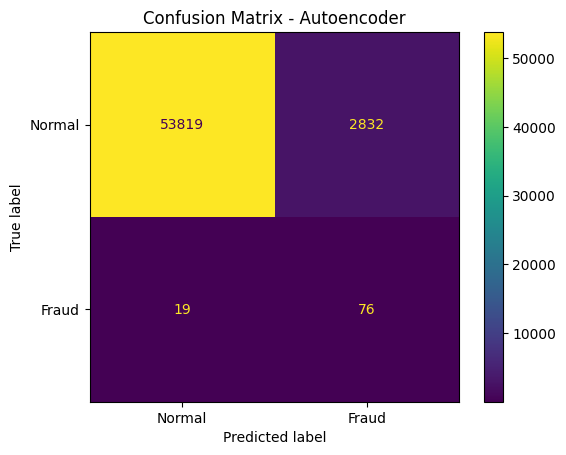

In [50]:
cm = confusion_matrix(y_test, y_pred_ae)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Fraud']
)

disp.plot()

plt.title('Confusion Matrix - Autoencoder')
plt.show()

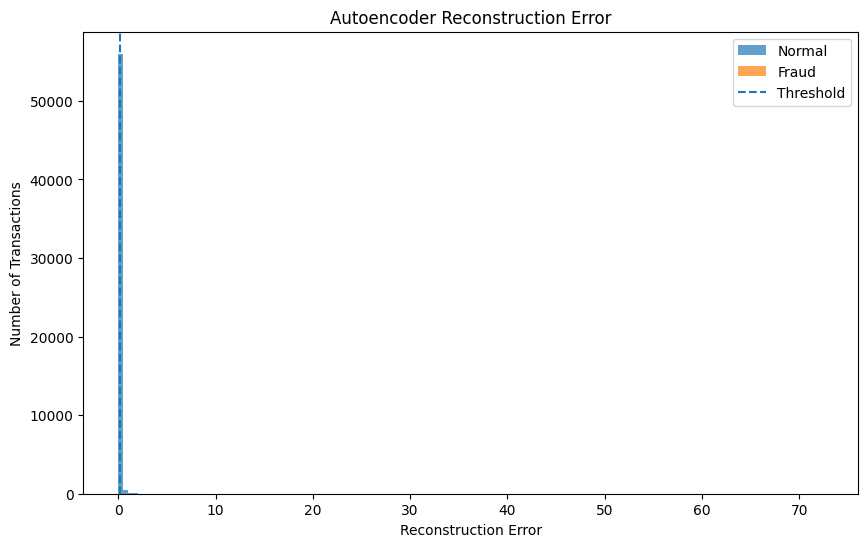

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    reconstruction_error[y_test == 0],
    bins=100,
    alpha=0.7,
    label='Normal'
)

plt.hist(
    reconstruction_error[y_test == 1],
    bins=100,
    alpha=0.7,
    label='Fraud'
)

plt.axvline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Transactions')
plt.title('Autoencoder Reconstruction Error')
plt.legend()
plt.show()

### Saving the Autoencoder

The trained Autoencoder, the `StandardScaler` (fitted on normal training data only) and the anomaly threshold are saved so the Streamlit app can load them without retraining.


In [52]:
import joblib

autoencoder.save('autoencoder_model.keras')
joblib.dump(scaler, 'autoencoder_scaler.pkl')
joblib.dump(float(threshold), 'autoencoder_threshold.pkl')

print('Saved: autoencoder_model.keras')
print('Saved: autoencoder_scaler.pkl')
print('Saved: autoencoder_threshold.pkl ->', float(threshold))


Saved: autoencoder_model.keras
Saved: autoencoder_scaler.pkl
Saved: autoencoder_threshold.pkl -> 0.21672034094443426


## Comparison Between Isolation Forest and Autoencoder

Both **Isolation Forest** and **Autoencoder** can be used for anomaly detection, but they identify anomalies using different approaches.

### General Difference

**Isolation Forest** is a tree-based machine learning algorithm. It identifies anomalies based on how easily observations can be isolated from the rest of the data.

**Autoencoder** is a Deep Learning model. It learns the patterns of normal transactions and identifies observations that cannot be reconstructed accurately as potential anomalies.

| Aspect                      | Isolation Forest                                | Autoencoder                                              |
| --------------------------- | ----------------------------------------------- | -------------------------------------------------------- |
| Model Type                  | Tree-based Ensemble Learning                    | Deep Learning / Neural Network                           |
| Main Idea                   | Isolates unusual observations                   | Reconstructs normal observations                         |
| Training Approach           | Learns patterns for identifying isolated points | Trained mainly on normal transactions                    |
| Anomaly Score               | Isolation/anomaly score                         | Reconstruction error                                     |
| Feature Scaling             | Generally not required                          | Important                                                |
| Computational Cost          | Relatively low                                  | Higher                                                   |
| Model Complexity            | Lower                                           | Higher                                                   |
| Interpretability            | Relatively easier                               | More complex                                             |
| Suitable for Large Datasets | Very suitable                                   | Suitable, but training is more computationally demanding |
| Threshold                   | Based on contamination / anomaly score          | Based on reconstruction-error threshold                  |

---

## Performance Comparison

The two models were evaluated on the same unseen test set.

| Metric          | Isolation Forest | Autoencoder |
| --------------- | ---------------: | ----------: |
| Accuracy        |           99.74% |      95.00% |
| Fraud Precision |           21.65% |       3.00% |
| Fraud Recall    |           22.11% |      82.00% |
| Fraud F1-score  |           21.88% |       5.00% |
| ROC-AUC         |           0.9320 |      0.8992 |
| PR-AUC          |           0.1775 |      0.6347 |

### Isolation Forest

The Isolation Forest achieved a **fraud precision of 21.65%** and a **fraud recall of 22.11%**.

This means that it identified a smaller proportion of the actual fraudulent transactions, but its fraud predictions had higher precision than those of the Autoencoder.

The model also achieved a **ROC-AUC of 0.9320**.

### Autoencoder

The Autoencoder achieved a much higher **fraud recall of 82%**, meaning that it detected a larger proportion of the actual fraudulent transactions.

However, its **fraud precision was only 3%**, indicating that many legitimate transactions were also classified as anomalies.

The Autoencoder achieved a **PR-AUC of 0.6347**, which was substantially higher than the Isolation Forest's **0.1775**.

---

## Why Do the Models Behave Differently?

The difference comes mainly from how each model defines an anomaly.

### Isolation Forest

Isolation Forest asks:

> **How easily can this transaction be isolated from the other transactions?**

An observation that can be isolated using relatively few random splits receives a higher anomaly score.

### Autoencoder

The Autoencoder asks:

> **How well can this transaction be reconstructed using the patterns learned from normal transactions?**

A transaction that is poorly reconstructed receives a higher reconstruction error and is classified as a potential anomaly when the error exceeds the selected threshold.

---

## Interpretation of the Results

The results show that the two models provide different trade-offs between **fraud detection and false positives**.

The Autoencoder detects considerably more fraudulent transactions, as shown by its **82% recall**, but it also produces many false positives, resulting in a **3% fraud precision**.

The Isolation Forest produces fewer fraud detections, with a **22.11% recall**, but achieves a higher fraud precision of **21.65%**.

The difference is also reflected in the PR-AUC values. The Autoencoder achieved **0.6347**, while Isolation Forest achieved **0.1775**. Since the dataset is highly imbalanced, PR-AUC is particularly useful for evaluating the ability of the models to identify the minority fraud class.

The ROC-AUC values are relatively high for both models, with Isolation Forest achieving **0.9320** and the Autoencoder achieving **0.8992**. However, ROC-AUC should not be considered alone because it can provide an optimistic view of performance in highly imbalanced datasets.

---

## Overall Comparison

There is no single metric that completely determines which model is preferable. The two models show different strengths:

* **Isolation Forest** is simpler, faster, and produces fewer false positives at the selected operating point, but it misses a large proportion of fraudulent transactions.
* **Autoencoder** detects a much larger proportion of fraudulent transactions and achieves substantially higher PR-AUC, but its current threshold produces a very large number of false positives.

Therefore, the choice between the two depends on the required balance between **detecting more fraudulent transactions** and **reducing false alarms**.

For this project, the comparison demonstrates that different anomaly detection approaches can produce substantially different results even when they are applied to the same dataset.


# Conclusions

## What We Learned

This project demonstrated how anomaly detection can be applied to credit card fraud detection in a highly imbalanced dataset. We learned that **accuracy alone is not sufficient** for evaluating fraud detection models, and that metrics such as **Precision, Recall, F1-score, ROC-AUC, and PR-AUC** provide a more meaningful evaluation.

We also learned that different anomaly detection techniques can produce different results. **Isolation Forest** identifies observations that are easier to isolate, while the **Autoencoder** learns the patterns of normal transactions and detects anomalies using reconstruction error.

## Model Strengths

### Isolation Forest

* Efficient and suitable for large datasets.
* Does not require feature scaling.
* Relatively simple and computationally efficient.
* Hyperparameter tuning improved the test PR-AUC compared with the initial model.
* Achieved higher fraud precision and ROC-AUC than the Autoencoder at the selected operating point.
* Feature interpretation was explored using **Permutation Importance and SHAP**.

### Autoencoder

* Can learn complex and nonlinear patterns.
* Learns the normal transaction structure without requiring fraudulent transactions during training.
* Achieved a high fraud recall of **82%**.
* Achieved a **PR-AUC of 0.6347**, showing strong ranking performance for the fraud class on the test set.

## Model Weaknesses

### Isolation Forest

* Fraud recall was relatively low at **22.11%**, meaning that many fraudulent transactions were not detected.
* Fraud precision was **21.65%**, so a considerable number of detected anomalies were legitimate transactions.
* Its performance depends on the selected hyperparameters and contamination value.

### Autoencoder

* Requires feature scaling and more computational resources.
* More complex to train and tune.
* Although it achieved **82% fraud recall**, its fraud precision was only **3%**, resulting in many false positives.
* Its classification performance is highly dependent on the selected reconstruction-error threshold.

## Possible Improvements

Although several improvements were already applied in this project, including **hyperparameter tuning, validation-based model selection, thresholding, SHAP analysis, Permutation Importance, and comparison with an Autoencoder**, further improvements could include:

* Perform more extensive threshold optimization using a validation set to achieve a desired precision-recall trade-off.
* Experiment with different Autoencoder architectures, such as different numbers of layers and latent dimensions.
* Apply regularization or dropout to the Autoencoder to improve generalization.
* Compare the current approaches with additional anomaly detection methods such as **One-Class SVM and Local Outlier Factor**.
* Explore supervised classification models as an additional benchmark, since fraud labels are available.
* Evaluate model performance over different thresholds using **Precision-Recall curves** and select an operating point based on the practical cost of false positives and false negatives.
* Investigate ensemble or hybrid approaches that combine anomaly scores from multiple models.
